<a href="https://colab.research.google.com/github/Anastasia-Pom/Machine-learning-2026/blob/main/%D0%9B%D0%A03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from operator import itemgetter
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from enum import Enum
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score
from sklearn.metrics import roc_curve, roc_auc_score
%matplotlib inline
import seaborn as sns
sns.set(style="ticks")
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from IPython.display import Image
class PredictionType(Enum):
    CLASSIFICATION = 1
    REGRESSION = 2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
drive_file_path = "/content/drive/MyDrive/synthetic_coffee_health_10000.csv"
data = pd.read_csv("/content/drive/MyDrive/synthetic_coffee_health_10000.csv")

data.head()

Mounted at /content/drive


,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,No,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,No,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [ ]:
def impute_column(dataset, column, strategy_param, fill_value_param=None):
    temp_data = dataset[[column]].values
    size = temp_data.shape[0]

    indicator = MissingIndicator()
    mask_missing_values_only = indicator.fit_transform(temp_data)

    imputer = SimpleImputer(strategy=strategy_param,
                            fill_value=fill_value_param)
    all_data = imputer.fit_transform(temp_data)

    missed_data = temp_data[mask_missing_values_only]
    filled_data = all_data[mask_missing_values_only]

    return all_data.reshape((size,)), filled_data, missed_data
def plot_hist_diff(old_ds, new_ds, cols):
    for c in cols:
        fig = plt.figure()
        ax = fig.add_subplot(111)
        ax.title.set_text('Поле - ' + str(c))
        old_ds[c].hist(bins=50, ax=ax, density=True, color='green')
        new_ds[c].hist(bins=50, ax=ax, color='blue', density=True, alpha=0.5)
        plt.show()

In [ ]:
data_cat_cols = ['Stress_Level']
data_cat_new = data[data_cat_cols].copy()
Stress_Level_cat_new_temp, _, _ = impute_column(data_cat_new, 'Stress_Level', 'most_frequent')
data_cat_new['Stress_Level'] = Stress_Level_cat_new_temp
stress = data_cat_new['Stress_Level']
pd_stress = pd.DataFrame(data={'Stress_Level':stress})
pd_stress['stress_codes'] = pd_stress['Stress_Level'].map({'Low':1, 'Medium':2, 'High':3})
pd_stress
#data.insert(loc=11, column='stress_codes', value=pd_stress['Stress_Level'].map({'Low':1, 'Medium':2, 'High':3}))
data.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,stress_codes,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,1,14.5,No,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,1,11.0,No,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,2,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,1,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,2,8.5,Mild,Student,0,1


In [ ]:
data_cat_cols = ['Occupation']
data_cat_new = data[data_cat_cols].copy()
Occupation_cat_new_temp, _, _ = impute_column(data_cat_new, 'Occupation', 'most_frequent')
data_cat_new['Occupation'] = Occupation_cat_new_temp
occup = data_cat_new['Occupation']
pd_occup = pd.DataFrame(data={'Occupation':occup})
pd_occup
#data.insert(loc=15, column='occupation_codes', value=pd_occup['Occupation'].map({'Other':1, 'Service':2, 'Student':3,'Office':4, 'Healthcare':5}))
data.head()

,ID,Age,Country,gender_codes,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,stress_codes,Physical_Activity_Hours,Health_Issues,Occupation,occupation_codes,Smoking,Alcohol_Consumption
0,1,40,Germany,1.0,3.5,328.1,7.5,Good,24.9,78,Low,1,14.5,No,Other,1,0,0
1,2,33,Germany,1.0,1.0,94.1,6.2,Good,20.0,67,Low,1,11.0,No,Service,2,0,0
2,3,42,Brazil,1.0,5.3,503.7,5.9,Fair,22.7,59,Medium,2,11.2,Mild,Office,4,0,0
3,4,53,Germany,1.0,2.6,249.2,7.3,Good,24.7,71,Low,1,6.6,Mild,Other,1,0,0
4,5,32,Spain,2.0,3.1,298.0,5.3,Fair,24.1,76,Medium,2,8.5,Mild,Student,3,0,1


In [ ]:
#data_cat_cols = ['Sleep_Quality']
#data_cat_new = data[data_cat_cols].copy()
#Occupation_cat_new_temp, _, _ = impute_column(data_cat_new, 'Sleep_Quality', 'most_frequent')
#data_cat_new['Sleep_Quality'] = Occupation_cat_new_temp
#occup = data_cat_new['Sleep_Quality']
#pd_occup = pd.DataFrame(data={'Sleep_Quality':occup})
#pd_occup
#data.insert(loc=15, column='Sleep_Quality_codes', value=pd_occup['Sleep_Quality'].map({'Bad':1, 'Fair':2, 'Good':3}))

data.drop("Sleep_Quality_codes", axis=1, inplace=True)
data.head()

,ID,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,stress_codes,Physical_Activity_Hours,occupation_codes,Smoking,Alcohol_Consumption
0,1,40,3.5,328.1,7.5,24.9,78,1,14.5,1,0,0
1,2,33,1.0,94.1,6.2,20.0,67,1,11.0,2,0,0
2,3,42,5.3,503.7,5.9,22.7,59,2,11.2,4,0,0
3,4,53,2.6,249.2,7.3,24.7,71,1,6.6,1,0,0
4,5,32,3.1,298.0,5.3,24.1,76,2,8.5,3,0,1


In [ ]:
class SimpleKNN:

    def fit(self, X_train: np.matrix, y_train: np.ndarray):
        """
        Метод обучения, который фактически не учится,
        а только запоминает обучающую выборку.
        Входные параметры:
        X_train - обучающая выборка (матрица объект-признак)
        y_train - обучающая выборка (вектор целевого признака)
        Возвращаемое значение: нет
        """
        #Сохраняем параметры в переменных класса
        self._X_train = X_train
        self._y_train = y_train

    def eucl_dist(self, p: np.ndarray, q: np.ndarray) -> float:
        """
        Вычисление Евклидова расстояния - https://en.wikipedia.org/wiki/Euclidean_distance
        Входные параметры:
        p, q - вектора в n-мерном пространстве признаков
        """
        return math.sqrt(sum([(pi - qi) ** 2 for pi, qi in zip (p, q)]))


    def predict_for_single_object(self, K: int, \
                prediction_type: PredictionType, \
                X_o: np.ndarray, \
                verbose = True) -> np.ndarray:
        """
        Метод предсказания для одного объекта.
        Входные параметры:
        K - гиперпараметр, количество соседей
        prediction_type - классификация или регрессия
        X_o - строка матрицы объект-признак, соответствующая объекту
        verbose - флаг детального вывода
        Возвращаемое значение: предсказанное значение целевого признака
        """
        # список соседей
        neighbors_list = []
        # *** Находим ближайшие точки ***
        # Перебираем все точки обучающей выборки
        for i in range(self._X_train.shape[0]):
            # получаем текущую точку
            data_train_current_x = [x for x in self._X_train[['x1','x2']].iloc[i]]
            # и значение ее y
            data_train_current_y = self._y_train[i]
            # вычисляем расстояние
            dist = self.eucl_dist(X_o, data_train_current_x)
            # сохраняем в список соседей
            temp_res = (data_train_current_y, dist, data_train_current_x)
            neighbors_list.append(temp_res)
        # *** сортируем список соседей по возрастанию расстояния ***
        # в кортеже элементы следуют в порядке (0,1,2), сортируем по первому элементу
        neighbors_list_sorted = sorted(neighbors_list, key=itemgetter(1))
        if verbose:
            print()
            print('**************************************')
            print('Проверяемая точка: ', X_o)
            print('**************************************')
            print('Вывод отсортированного списка соседей:')
            dist_list = []
            for cur_y, cur_dist, temp_x_1_2 in neighbors_list_sorted:
                temp_x1, temp_x2 = temp_x_1_2
                print('X1={0}, X2={1}, y={2}, расстояние={3:.2f}'.format(temp_x1, temp_x2, cur_y, cur_dist))
                dist_list.append(cur_dist)
            print()
            print('Вывод расстояния для отсортированного списка соседей:')
            plt.plot(dist_list)
            plt.show()
        # Оставим только K ближайших соседей
        K_neighbors_list_sorted = neighbors_list_sorted[:K]
        if verbose:
            print('Вывод К ближайших соседей:')
            x1_list = []
            x2_list = []
            for cur_y, cur_dist, temp_x_1_2 in K_neighbors_list_sorted:
                temp_x1, temp_x2 = temp_x_1_2
                x1_list.append(temp_x1)
                x2_list.append(temp_x2)
                print('X1={0}, X2={1}, y={2}, расстояние={3:.2f}'.format(temp_x1, temp_x2, cur_y, cur_dist))
            print()
            print('Визуализация К ближайших соседей:')
            plt.plot(self._X_train['x1'], self._X_train['x2'], 'b.', \
                     x1_list, x2_list,  'g*', \
                    [X_o[0]], [X_o[1]], 'ro')
            plt.show()
        # Результат - классификация или регрессия
        if prediction_type == PredictionType.REGRESSION:
            # используем numpy для вычисления среднего значения
            arr = np.array([x for x,_,_ in K_neighbors_list_sorted])
            # возвращаем среднее значение
            return np.mean(arr)
        elif prediction_type == PredictionType.CLASSIFICATION:
            k_y_list = [y for y,_,_ in K_neighbors_list_sorted]
            # группируем с количеством метки классов,
            # соответствующие K ближайшим соседям
            k_y_list_grouped_temp = np.unique(k_y_list, return_counts=True)
            k_y_list_grouped = [[key, cnt] for key, cnt in zip(k_y_list_grouped_temp[0], k_y_list_grouped_temp[1])]
            # сортируем по количеству по убыванию
            k_y_list_grouped_sorted = sorted(k_y_list_grouped, key=itemgetter(1), reverse=True)
            if verbose:
                print('Классы, соответствующие К ближайшим соседям:')
                for i in k_y_list_grouped_sorted:
                    print('класс={0}, количество элементов={1}'.format(i[0], i[1]))
            # возвращаеv метку класса из первой строки отсортированного массива
            # то есть того класса, к которому принадлежит наибольшее количество соседей
            return k_y_list_grouped_sorted[0][0]
        else:
            raise Exception('Неизвестный тип предсказания')


    def predict(self, K: int, \
                prediction_type: PredictionType, \
                X_test: np.matrix,
                verbose = True) -> np.ndarray:
        """
        Метод предсказания.
        Входные параметры:
        K - гиперпараметр, количество соседей
        prediction_type - классификация или регрессия
        X_test - тестовая выборка (матрица объект-признак)
        Возвращаемое значение: предсказанный вектор целевого признака
        """
        # Перебираем все точки тестовой выборки
        test_data_temp = []
        for i in range(X_test.shape[0]):
            # получаем текущую точку
            data_test_current_x = [x for x in X_test.iloc[i]]
            test_data_temp.append(data_test_current_x)
        return [self.predict_for_single_object(K=K, \
                prediction_type=prediction_type, \
                X_o=i, verbose=verbose) for i in test_data_temp]

In [ ]:
def class_proportions(array: np.ndarray) -> Dict[int, Tuple[int, float]]:
    """
    Вычисляет пропорции классов
    array - массив, содержащий метки классов
    """
    # Получение меток классов и количества меток каждого класса
    labels, counts = np.unique(array, return_counts=True)
    # Превращаем количество меток в процент их встречаемости
    # делим количество меток каждого класса на общее количество меток
    counts_perc = counts/array.size
    # Теперь sum(counts_perc)==1.0
    # Создаем результирующий словарь,
    # ключом словаря явлется метка класса,
    # а значением словаря процент встречаемости метки
    res = dict()
    for label, count2 in zip(labels, zip(counts, counts_perc)):
        res[label] = count2
    return res

def print_class_proportions(array: np.ndarray):
    """
    Вывод пропорций классов
    """
    proportions = class_proportions(array)
    if len(proportions)>0:
        print('Метка \t Количество \t Процент встречаемости')
    for i in proportions:
        val, val_perc = proportions[i]
        val_perc_100 = round(val_perc * 100, 2)

In [ ]:
data_X_train, data_X_test,data_y_train, data_y_test = train_test_split(
    data, data['stress_codes'], test_size=0.2, random_state=1)
cl1_2 = KNeighborsClassifier(n_neighbors=10)
cl1_2.fit(data_X_train, data_y_train)
target1_2 = cl1_2.predict(data_X_test)
len(target1_2), target1_2

(2000, array([1, 2, 1, ..., 1, 1, 1]))

In [ ]:
print_class_proportions(data_y_train)
print_class_proportions(data['stress_codes'])

Метка 	 Количество 	 Процент встречаемости
Метка 	 Количество 	 Процент встречаемости


In [ ]:
def accuracy_score_for_classes(
    y_true: np.ndarray,
    y_pred: np.ndarray) -> Dict[int, float]:
    """
    Вычисление метрики accuracy для каждого класса
    y_true - истинные значения классов
    y_pred - предсказанные значения классов
    Возвращает словарь: ключ - метка класса,
    значение - Accuracy для данного класса
    """
    # Для удобства фильтрации сформируем Pandas DataFrame
    d = {'t': y_true, 'p': y_pred}
    df = pd.DataFrame(data=d)
    # Метки классов
    classes = np.unique(y_true)
    # Результирующий словарь
    res = dict()
    # Перебор меток классов
    for c in classes:
        # отфильтруем данные, которые соответствуют
        # текущей метке класса в истинных значениях
        temp_data_flt = df[df['t']==c]
        # расчет accuracy для заданной метки класса
        temp_acc = accuracy_score(
            temp_data_flt['t'].values,
            temp_data_flt['p'].values)
        # сохранение результата в словарь
        res[c] = temp_acc
    return res

def print_accuracy_score_for_classes(
    y_true: np.ndarray,
    y_pred: np.ndarray):
    """
    Вывод метрики accuracy для каждого класса
    """
    accs = accuracy_score_for_classes(y_true, y_pred)
    if len(accs)>0:
        print('Метка \t Accuracy')
    for i in accs:
        print('{} \t {}'.format(i, accs[i]))

In [ ]:
print_accuracy_score_for_classes(data_y_test, target1_2)

Метка 	 Accuracy
1 	 0.9771591720199857
2 	 0.03333333333333333
3 	 0.0


In [ ]:
from IPython.display import Image
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import KFold, RepeatedKFold, LeaveOneOut, LeavePOut, ShuffleSplit, StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import learning_curve, validation_curve
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")

In [ ]:
scores = cross_val_score(KNeighborsClassifier(n_neighbors=2),
                         data,data['stress_codes'], cv=3)
scores

array([0.69946011, 0.16951695, 0.10261026])

In [ ]:
np.mean(scores)

np.float64(0.32386244023322547)

In [ ]:
X = ["a", "b", "c"]
kf = KFold(n_splits=3)
for train, test in kf.split(X):
    print("%s %s" % (train, test))
kf = KFold(n_splits=5)
scores = cross_val_score(KNeighborsClassifier(n_neighbors=2),
                         data, data['stress_codes'], scoring='f1_weighted',
                         cv=kf)
scores

[1 2] [0]
[0 2] [1]
[0 1] [2]


array([0.5921543 , 0.5431219 , 0.56858357, 0.56304059, 0.58272471])

In [ ]:
n_range = np.array(range(5,65,5))
tuned_parameters = [{'n_neighbors': n_range}]
tuned_parameters
clf_gs = GridSearchCV(KNeighborsClassifier(), tuned_parameters, cv=5, scoring='accuracy')
clf_gs.fit(data_X_train, data_y_train)
clf_gs.cv_results_
clf_gs.best_params_

{'n_neighbors': np.int64(55)}

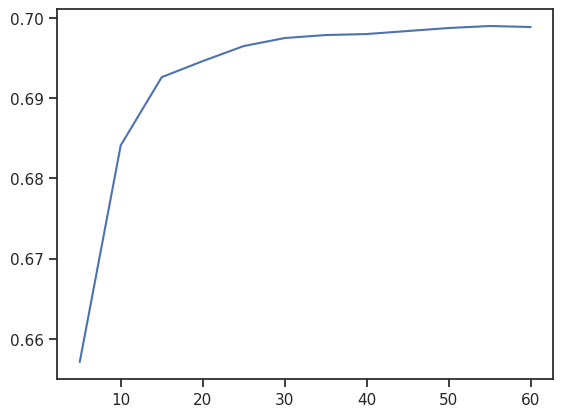

In [ ]:
plt.plot(n_range, clf_gs.cv_results_['mean_test_score'])

In [ ]:
clf_rs = RandomizedSearchCV(KNeighborsClassifier(), tuned_parameters, cv=5, scoring='accuracy')
clf_rs.fit(data_X_train, data_y_train)
clf_rs.best_score_, clf_rs.best_params_

(np.float64(0.699), {'n_neighbors': np.int64(55)})